# AIM · 6주차 실습
## VAE ② 생성 제어와 잠재 공간 실험

**대상:** Python·PyTorch 기초 이수자 / **권장:** Google Colab Python 3, GPU 선택 가능.

5주차의 손실과 재매개화 코드를 독립적으로 다시 포함한다. 실습은 β 비교와 작은 CVAE 학습을 수행한다. GPU가 없으면 각 학습 epoch와 TRAIN_N을 줄이고 기본 분석을 우선한다.

### 학습 목표
- β-VAE 실험을 같은 손실 척도로 비교한다.
- posterior collapse의 징후와 한계를 설명한다.
- 조건부 VAE로 숫자 라벨을 제어하며 생성한다.

### 실행 방법
1. Colab에서 `파일 → 노트북 업로드`로 이 파일을 엽니다.
2. GPU를 사용할 경우 `런타임 → 런타임 유형 변경`에서 GPU를 선택합니다.
3. 위에서 아래로 셀을 실행합니다. 이전 주차 파일이나 별도 Python 모듈은 필요 없습니다.
4. Colab 기본 torch·torchvision을 우선 사용합니다. import가 실패하면 새 런타임에서 시작하세요.
   로컬 환경은 루트 `환경설정.md`를 참고하세요. 데이터 최초 다운로드에는 인터넷이 필요합니다.
5. 학습이 길면 `TRAIN_N`, `EPOCHS` 또는 `STEPS`를 줄입니다. 작은 실험의 품질은 보장되지 않습니다.

**시간 운영:** 실습 셀 번호가 아니라 아래 § 구간으로 진행합니다. 준비·다운로드는 수업 시작에,
핵심 실행은 50–75분에, 관찰 답변은 75–85분에 수행합니다. 심화와 자율 과제는 수업 밖에서 진행합니다.

**재현성:** 고정 seed도 다른 GPU·라이브러리 버전의 완전히 같은 수치를 보장하지 않습니다.
실제 출력과 예측을 구분해 기록하세요. `outputs/`는 현재 실행 폴더에 생성됩니다.

## §1 · 환경 확인

첫 실행에서 버전과 device를 확인합니다. CPU도 지원하며 설치가 필요한 경우 환경설정 문서를 먼저 읽습니다.

In [1]:
import os, sys, math, random, copy, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from IPython.display import display

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# QUICK=True: 수업용 일부 데이터. False: 데이터/학습 예산 확대.
QUICK = True
# 검증 제작자용 축소 모드. 수강생은 설정할 필요가 없습니다.
SMOKE = os.environ.get('AIM_SMOKE', '0') == '1'
DATA_ROOT = Path(os.environ.get('AIM_DATA_ROOT', './data'))
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_all()
print('Python', sys.version.split()[0], '| torch', torch.__version__,
      '| torchvision', torchvision.__version__, '| device', DEVICE)
print('QUICK:', QUICK, '| SMOKE:', SMOKE, '| data:', DATA_ROOT.resolve())

def image_grid(images, titles=None, cols=8, title='', normalized=False):
    images = images.detach().cpu()
    if normalized: images = (images * .5 + .5).clamp(0, 1)
    n = len(images); rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.35, rows*1.55), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            im = images[i]
            ax.imshow(im.squeeze(0) if im.shape[0]==1 else im.permute(1,2,0),
                      cmap='gray', vmin=0, vmax=1)
            if titles is not None: ax.set_title(str(titles[i]), fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    return fig

def num_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

Python 3.13.9 | torch 2.14.0+cpu | torchvision 0.29.0+cpu | device cpu
QUICK: True | SMOKE: False | data: D:\AIM\.study-data


In [2]:
DATASET = 'mnist'
TRAIN_N = 256 if SMOKE else (4096 if QUICK else 40000)
VAL_N = 128 if SMOKE else (1024 if QUICK else 5000)
TEST_N = 128 if SMOKE else (1024 if QUICK else 10000)
BATCH = 64 if SMOKE else 128
EPOCHS = 1 if SMOKE else (8 if QUICK else 20)

## §2 · 데이터와 분할

공식 train을 고정 인덱스로 나누고 test는 마지막에만 사용합니다. QUICK의 평가 숫자는 전체 공식 test의 성능이 아닌 고정 부분집합 성능입니다. MNIST 계열은 0~1, CIFAR10만 -1~1로 변환합니다.

split sizes: 4096 1024 1024
shape: torch.Size([128, 1, 28, 28]) dtype: torch.float32 range: (0.0, 1.0)


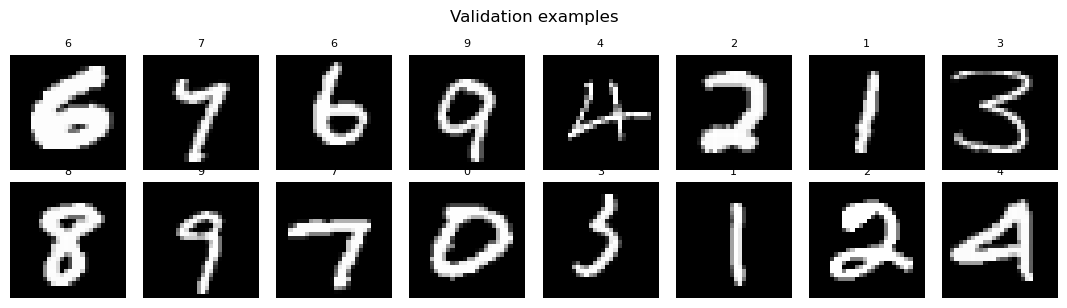

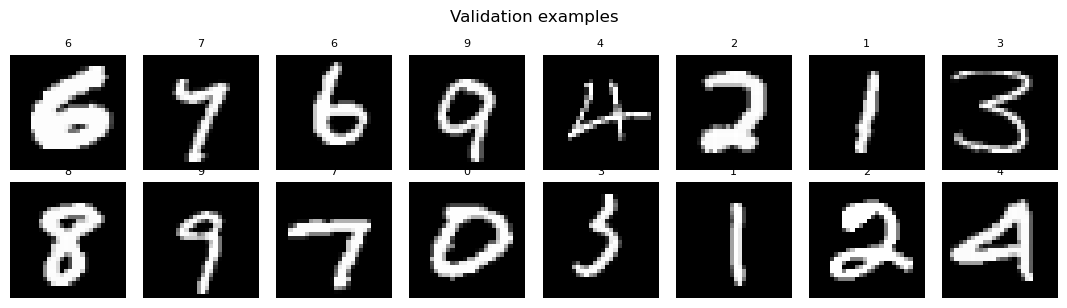

In [3]:
# DATASET은 앞의 설정 셀에서 지정합니다.train/valは公式trainから分割。
def vision_loaders(name, augment=False):
    cls = {'fashion':datasets.FashionMNIST, 'cifar':datasets.CIFAR10, 'mnist':datasets.MNIST}[name]
    base = [transforms.ToTensor()]
    if name=='cifar': base += [transforms.Normalize((.5,)*3, (.5,)*3)]
    eval_tf = transforms.Compose(base)
    train_tf = transforms.Compose(([transforms.RandomCrop(32,padding=4),
                                    transforms.RandomHorizontalFlip()] if augment else []) + base)
    train_ds = cls(DATA_ROOT, train=True, download=True, transform=train_tf)
    val_ds = cls(DATA_ROOT, train=True, download=True, transform=eval_tf)
    test_ds = cls(DATA_ROOT, train=False, download=True, transform=eval_tf)
    ids = torch.randperm(len(train_ds), generator=torch.Generator().manual_seed(SEED))
    n_val = 5000 if name=='cifar' else 6000
    train_ids = ids[n_val:][:TRAIN_N].tolist()
    val_ids = ids[:n_val][:VAL_N].tolist()
    test_ids = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(SEED+1))[:TEST_N].tolist()
    assert not (set(train_ids) & set(val_ids))
    train = DataLoader(Subset(train_ds,train_ids), batch_size=BATCH, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED), num_workers=0)
    val = DataLoader(Subset(val_ds,val_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    test = DataLoader(Subset(test_ds,test_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    return train,val,test

train_loader, val_loader, test_loader = vision_loaders(DATASET)
xb,yb = next(iter(val_loader))
print('split sizes:', *(len(dl.dataset) for dl in [train_loader,val_loader,test_loader]))
print('shape:', xb.shape, 'dtype:', xb.dtype, 'range:', (xb.min().item(),xb.max().item()))
image_grid(xb[:16], yb[:16].tolist(), title='Validation examples', normalized=DATASET=='cifar')

## §3 · VAE와 ELBO 구현

decoder는 logits를 출력합니다. recon은 픽셀 합, KL은 latent 합, 최종 손실은 배치 평균입니다. 평가는 1-sample MC negative ELBO이며 그림의 μ 재구성과 구분합니다.

In [4]:
def reparameterize(mu,logvar):
    return mu + torch.exp(.5*logvar)*torch.randn_like(mu)

def gaussian_kl(mu,logvar):
    # shape [B,Z] 유지: 차원별 진단에 사용
    return .5*(mu.pow(2)+logvar.exp()-1-logvar)

class VAE(nn.Module):
    def __init__(self,zdim=2,conditional=False):
        super().__init__(); self.zdim=zdim; self.conditional=conditional
        cond=10 if conditional else 0
        self.encoder=nn.Sequential(nn.Linear(784+cond,256),nn.ReLU())
        self.mu_head=nn.Linear(256,zdim); self.lv_head=nn.Linear(256,zdim)
        self.decoder=nn.Sequential(nn.Linear(zdim+cond,256),nn.ReLU(),nn.Linear(256,784))
    def condition(self,y):
        return F.one_hot(y,num_classes=10).float()
    def encode(self,x,y=None):
        h=x.flatten(1)
        if self.conditional:
            assert y is not None; h=torch.cat([h,self.condition(y)],1)
        h=self.encoder(h)
        return self.mu_head(h),self.lv_head(h)
    def decode(self,z,y=None):
        if self.conditional:
            assert y is not None; z=torch.cat([z,self.condition(y)],1)
        return self.decoder(z).view(-1,1,28,28)
    def forward(self,x,y=None,sample=True):
        mu,lv=self.encode(x,y)
        z=reparameterize(mu,lv) if sample else mu
        return self.decode(z,y),mu,lv

def vae_terms(logits,x,mu,logvar):
    recon=F.binary_cross_entropy_with_logits(logits,x,reduction='none').flatten(1).sum(1)
    kl=gaussian_kl(mu,logvar).sum(1)
    return recon,kl

def vae_epoch(model,loader,optimizer=None,beta=1.0):
    training=optimizer is not None; model.train(training)
    total_r=total_k=count=0
    with torch.set_grad_enabled(training):
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            logits,mu,lv=model(x,y,sample=True)
            recon,kl=vae_terms(logits,x,mu,lv); loss=(recon+beta*kl).mean()
            assert torch.isfinite(loss), 'Nonfinite VAE loss: inspect logvar and learning rate'
            if training: loss.backward(); optimizer.step()
            total_r+=recon.detach().sum().item(); total_k+=kl.detach().sum().item(); count+=len(x)
    r,k=total_r/count,total_k/count
    return dict(recon=r,kl=k,nelbo=r+k,objective=r+beta*k)

def eval_vae(model,loader):
    # 평가 난수를 고정하고 훈련 RNG 흐름은 복원. 1-sample MC estimate.
    was_training=model.training
    with torch.random.fork_rng(devices=list(range(torch.cuda.device_count()))):
        torch.manual_seed(12345)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(12345)
        result=vae_epoch(model,loader)
    model.train(was_training)
    return result

def fit_vae(beta=1.,zdim=2,conditional=False,epochs=EPOCHS,warmup=False):
    seed_all(); model=VAE(zdim,conditional).to(DEVICE)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    history=[]; best=float('inf'); state=None; start=time.perf_counter()
    # 매 조건 같은 shuffle 난수열에서 시작하도록 generator도 초기화
    train_loader.generator.manual_seed(SEED)
    for ep in range(epochs):
        effective=beta*min(1.,(ep+1)/max(1,epochs//2)) if warmup else beta
        tr=vae_epoch(model,train_loader,opt,effective); va=eval_vae(model,val_loader)
        history.append(dict(epoch=ep+1,beta=effective,train_recon=tr['recon'],train_kl=tr['kl'],
                            val_recon=va['recon'],val_kl=va['kl'],val_nelbo=va['nelbo']))
        # 각 beta의 훈련 목적에 맞춰 checkpoint 선택. 조건 간 공통 평가 척도는 R+K.
        selection=va['recon']+beta*va['kl']
        if selection<best: best=selection; state=cpu_state(model)
        print(f"epoch {ep+1} beta={effective:.2f}: recon={va['recon']:.2f} KL={va['kl']:.2f} NELBO={va['nelbo']:.2f}")
    model.load_state_dict(state); model.eval()
    return model,history,time.perf_counter()-start

def plot_vae(history):
    fig,axes=plt.subplots(1,3,figsize=(11,3))
    for ax,key in zip(axes,['recon','kl','nelbo']):
        ax.plot([r['epoch'] for r in history],[r['val_'+key] for r in history],label='validation')
        if key!='nelbo': ax.plot([r['epoch'] for r in history],[r['train_'+key] for r in history],label='train')
        ax.set_title(key); ax.set_xlabel('epoch'); ax.grid(alpha=.2); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

@torch.no_grad()
def recon_and_samples(model):
    model.eval(); x,y=next(iter(val_loader)); x,y=x[:8].to(DEVICE),y[:8].to(DEVICE)
    logits,mu,lv=model(x,y,sample=False)
    image_grid(torch.cat([x,logits.sigmoid()]),title='Top: input / Bottom: decode(mu)')
    seed_all(123); z=torch.randn(32,model.zdim,device=DEVICE)
    labels=torch.arange(32,device=DEVICE)%10
    image_grid(model.decode(z,labels).sigmoid(),title='Prior sample: displayed pixel probabilities')
    return mu

## §4 · β 3조건 비교

같은 초기화·분할·shuffle 예산으로 각 모델을 새로 학습합니다. 조건별 선택은 R+βK, 비교 보고는 공통 R+K입니다.

epoch 1 beta=0.25: recon=218.54 KL=17.59 NELBO=236.13
epoch 2 beta=0.25: recon=202.54 KL=18.09 NELBO=220.63
epoch 3 beta=0.25: recon=184.96 KL=19.61 NELBO=204.57
epoch 4 beta=0.25: recon=155.87 KL=26.11 NELBO=181.98
epoch 5 beta=0.25: recon=141.73 KL=28.20 NELBO=169.94
epoch 6 beta=0.25: recon=135.15 KL=28.02 NELBO=163.17
epoch 7 beta=0.25: recon=130.77 KL=27.39 NELBO=158.16
epoch 8 beta=0.25: recon=127.18 KL=27.67 NELBO=154.85
epoch 1 beta=1.00: recon=217.82 KL=10.32 NELBO=228.15
epoch 2 beta=1.00: recon=205.62 KL=7.41 NELBO=213.03
epoch 3 beta=1.00: recon=189.43 KL=8.62 NELBO=198.05
epoch 4 beta=1.00: recon=169.65 KL=10.80 NELBO=180.45
epoch 5 beta=1.00: recon=150.31 KL=13.51 NELBO=163.81
epoch 6 beta=1.00: recon=142.96 KL=13.54 NELBO=156.50
epoch 7 beta=1.00: recon=138.46 KL=13.45 NELBO=151.91
epoch 8 beta=1.00: recon=135.71 KL=13.42 NELBO=149.14
epoch 1 beta=4.00: recon=221.56 KL=4.24 NELBO=225.79
epoch 2 beta=4.00: recon=210.71 KL=2.54 NELBO=213.25
epoch 3 beta=4.00: recon=199.63 

[{'beta': 0.25,
  'seconds': 1.85,
  'recon': 127.17653751373291,
  'kl': 27.674540758132935,
  'nelbo': 154.85107827186584,
  'objective': 154.85107827186584},
 {'beta': 1.0,
  'seconds': 1.95,
  'recon': 135.71437072753906,
  'kl': 13.424121856689453,
  'nelbo': 149.13849258422852,
  'objective': 149.13849258422852},
 {'beta': 4.0,
  'seconds': 1.92,
  'recon': 155.43447875976562,
  'kl': 5.161322116851807,
  'nelbo': 160.59580087661743,
  'objective': 160.59580087661743}]

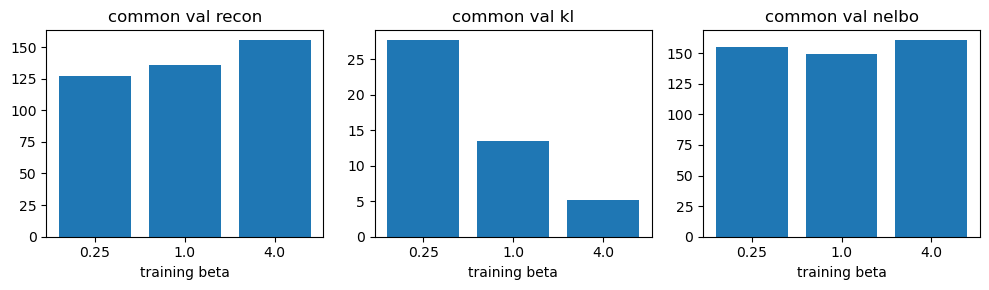

539

In [5]:
betas=[.25,1.,4.]; models={}; histories={}; rows=[]
for beta in betas:
    m,h,seconds=fit_vae(beta=beta,zdim=8)
    models[beta]=m; histories[beta]=h; metrics=eval_vae(m,val_loader)
    rows.append(dict(beta=beta,seconds=round(seconds,2),**metrics))
display(rows)
fig,axes=plt.subplots(1,3,figsize=(10,3))
for ax,key in zip(axes,['recon','kl','nelbo']):
    ax.bar([str(r['beta']) for r in rows],[r[key] for r in rows]); ax.set(xlabel='training beta',title='common val '+key)
plt.tight_layout(); plt.show()
(OUT/'beta_comparison.json').write_text(json.dumps(rows,indent=2))

**관찰·토론**

objective는 eval β=1이므로 nelbo와 같습니다. 훈련 β를 곱한 total들을 직접 비교하면 왜 잘못된 결론이 나오나요?

## §4-시각화 · 같은 z와 같은 입력

같은 z의 의미가 서로 다른 모델에서 정렬된다는 보장은 없습니다. 난수 차이를 줄이는 비교입니다.

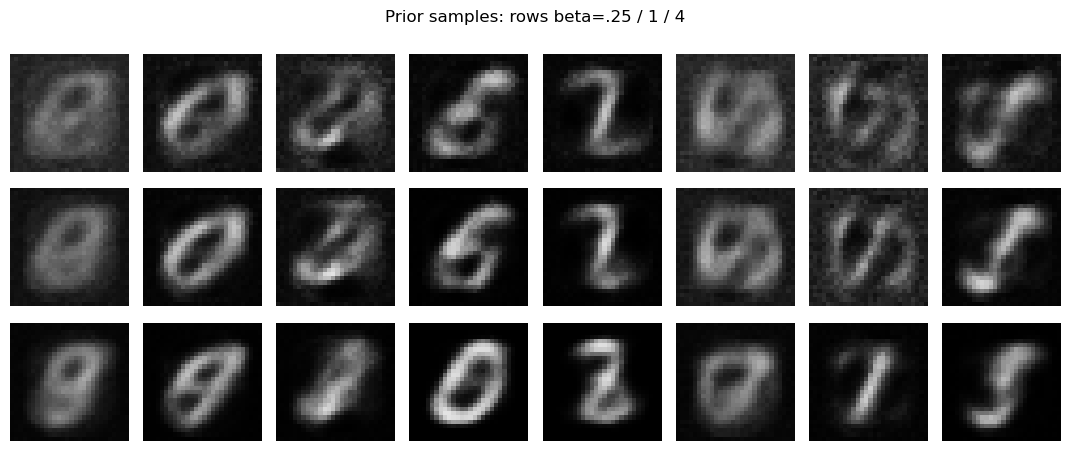

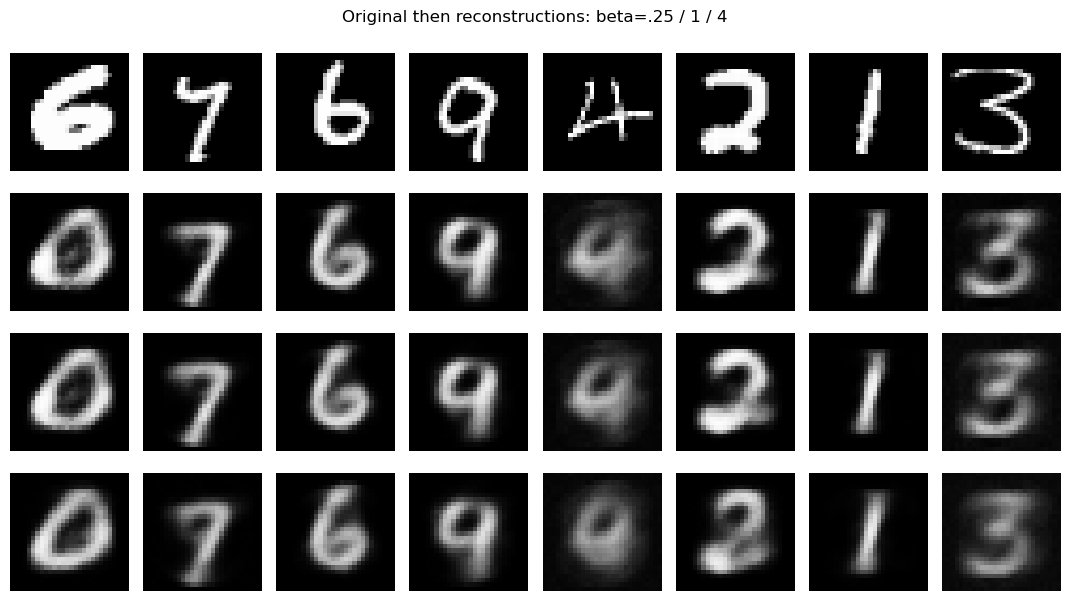

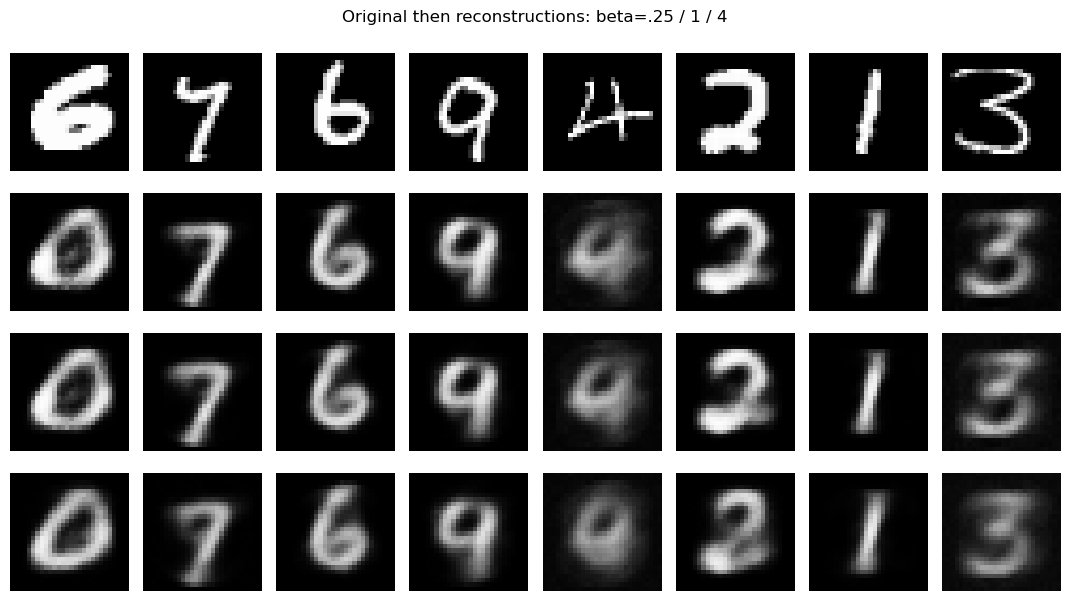

In [6]:
seed_all(123); fixed_z=torch.randn(8,8,device=DEVICE)
x,y=next(iter(val_loader)); x=x[:8].to(DEVICE)
samples=[]; reconstructions=[]
with torch.no_grad():
    for beta in betas:
        m=models[beta]; m.eval()
        samples.append(m.decode(fixed_z).sigmoid())
        reconstructions.append(m(x,sample=False)[0].sigmoid())
image_grid(torch.cat(samples),title='Prior samples: rows beta=.25 / 1 / 4')
image_grid(torch.cat([x]+reconstructions),title='Original then reconstructions: beta=.25 / 1 / 4')

## §5 · 차원별 KL과 traversal

collapse 진단은 작은 KL 하나만으로 끝내지 않습니다.

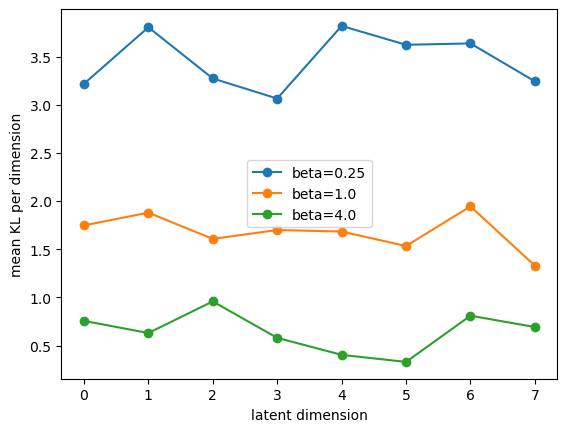

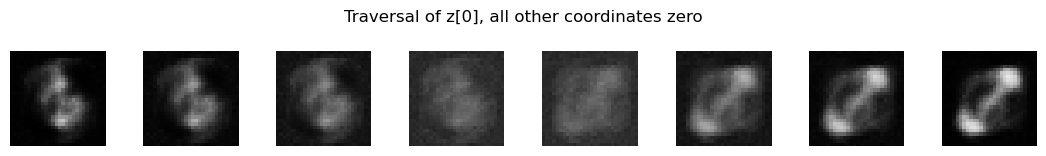

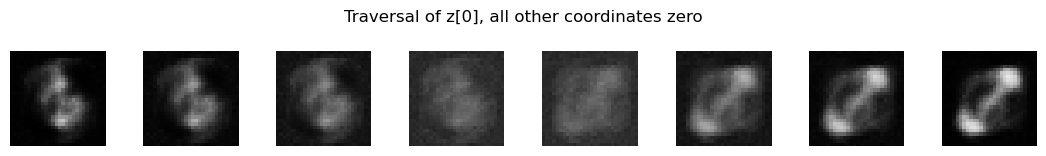

In [7]:
kl_rows=[]
with torch.no_grad():
    for beta in betas:
        parts=[]
        for x,y in val_loader:
            mu,lv=models[beta].encode(x.to(DEVICE)); parts.append(gaussian_kl(mu,lv).cpu())
        kl_rows.append(torch.cat(parts).mean(0))
for beta,k in zip(betas,kl_rows): plt.plot(range(8),k,marker='o',label=f'beta={beta}')
plt.xlabel('latent dimension'); plt.ylabel('mean KL per dimension'); plt.legend(); plt.show()
base_z=torch.zeros(8,8,device=DEVICE); base_z[:,0]=torch.linspace(-3,3,8,device=DEVICE)
with torch.no_grad(): traversal=models[1.].decode(base_z).sigmoid()
image_grid(traversal,title='Traversal of z[0], all other coordinates zero')

**관찰·토론**

변화가 거의 없는 차원이 있나요? latent를 바꾸어도 그림이 같다면 어떤 추가 실험을 하겠나요?

## §6 · 조건부 VAE 학습

one-hot label을 encoder와 decoder에 모두 넣습니다. 조건부 prior는 N(0,I)로 고정합니다.

epoch 1 beta=1.00: recon=226.94 KL=15.21 NELBO=242.15
epoch 2 beta=1.00: recon=204.61 KL=9.13 NELBO=213.74
epoch 3 beta=1.00: recon=188.29 KL=7.94 NELBO=196.23
epoch 4 beta=1.00: recon=176.18 KL=7.06 NELBO=183.24
epoch 5 beta=1.00: recon=168.47 KL=6.15 NELBO=174.62
epoch 6 beta=1.00: recon=163.24 KL=5.68 NELBO=168.91
epoch 7 beta=1.00: recon=159.79 KL=5.16 NELBO=164.95
epoch 8 beta=1.00: recon=156.93 KL=4.94 NELBO=161.86
epoch 9 beta=1.00: recon=154.35 KL=4.86 NELBO=159.21
epoch 10 beta=1.00: recon=152.24 KL=4.83 NELBO=157.07
epoch 11 beta=1.00: recon=150.77 KL=4.52 NELBO=155.29
epoch 12 beta=1.00: recon=149.06 KL=4.55 NELBO=153.62
epoch 13 beta=1.00: recon=147.77 KL=4.54 NELBO=152.31
epoch 14 beta=1.00: recon=146.69 KL=4.44 NELBO=151.13
epoch 15 beta=1.00: recon=145.48 KL=4.48 NELBO=149.96
epoch 16 beta=1.00: recon=144.82 KL=4.26 NELBO=149.08
epoch 17 beta=1.00: recon=143.79 KL=4.34 NELBO=148.13
epoch 18 beta=1.00: recon=143.00 KL=4.36 NELBO=147.36
epoch 19 beta=1.00: recon=142.45 KL=

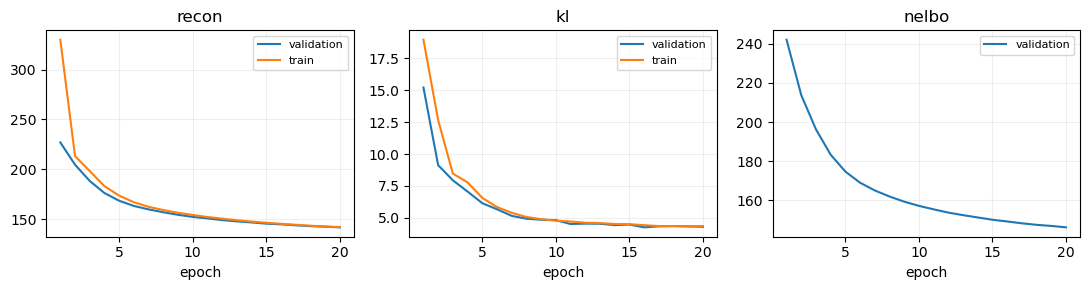

CVAE val metrics: {'recon': 141.77051734924316, 'kl': 4.304136097431183, 'nelbo': 146.07465344667435, 'objective': 146.07465344667435}


In [8]:
CVAE_EPOCHS = 1 if SMOKE else max(20,EPOCHS)
# 조건 y의 역할을 작은 예산에서도 관찰하기 쉽게 CVAE latent는 2차원으로 제한합니다.
# 앞의 무조건부 beta 실험(8차원)과는 별도 과제이며 성능을 직접 순위 비교하지 않습니다.
cvae,c_history,seconds=fit_vae(beta=1.,zdim=2,conditional=True,epochs=CVAE_EPOCHS)
plot_vae(c_history)
print('CVAE val metrics:',eval_vae(cvae,val_loader))

## §7 · 10×8 조건부 생성

행마다 라벨을 고정하고 열마다 같은 z를 공유합니다.

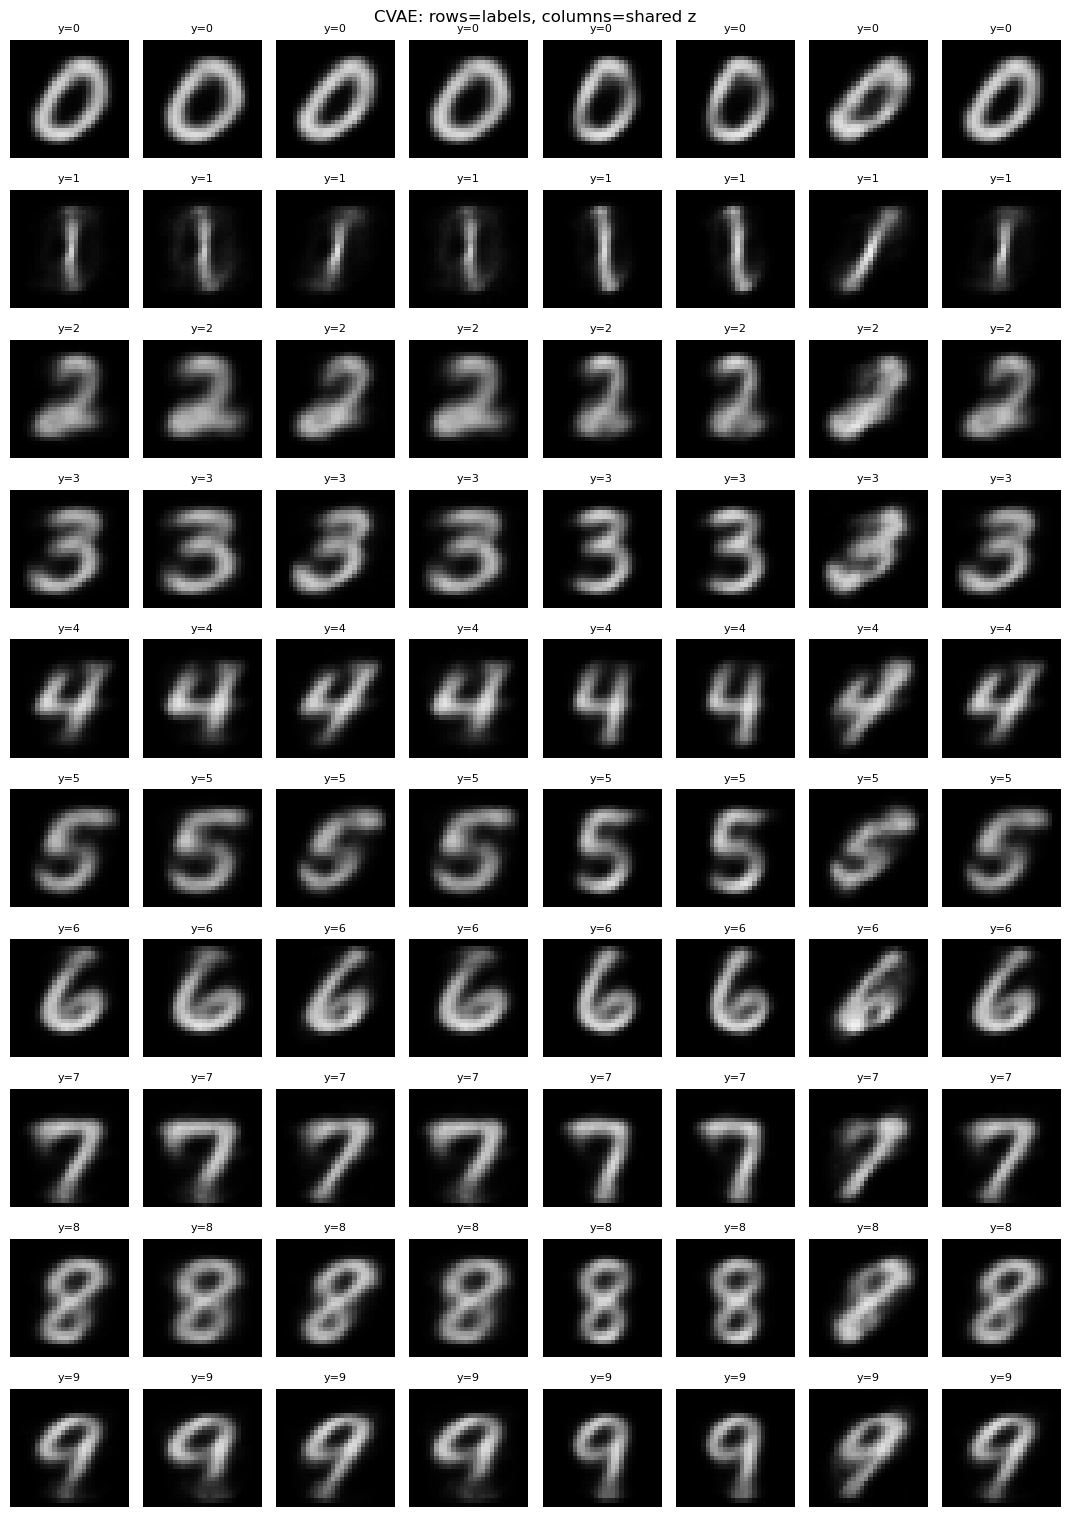

same z / different label mean logit difference: 1.6359999179840088
VAE beta chosen by common val NELBO: 1.0 test: {'recon': 132.30339241027832, 'kl': 14.276363968849182, 'nelbo': 146.5797563791275, 'objective': 146.5797563791275}
CVAE test (separate conditional task): {'recon': 140.09399795532227, 'kl': 4.441392183303833, 'nelbo': 144.5353901386261, 'objective': 144.5353901386261}


In [9]:
seed_all(123); z=torch.randn(8,cvae.zdim,device=DEVICE).repeat(10,1)
y=torch.arange(10,device=DEVICE).repeat_interleave(8)
with torch.no_grad(): probs=cvae.decode(z,y).sigmoid()
image_grid(probs,[f'y={i}' for i in y.tolist()],title='CVAE: rows=labels, columns=shared z')
assert probs.shape==(80,1,28,28) and torch.isfinite(probs).all()
with torch.no_grad():
    a=cvae.decode(z[:8],torch.zeros(8,dtype=torch.long,device=DEVICE))
    b=cvae.decode(z[:8],torch.ones(8,dtype=torch.long,device=DEVICE))
print('same z / different label mean logit difference:',(a-b).abs().mean().item())
chosen=min(rows,key=lambda r:r['nelbo'])['beta']
print('VAE beta chosen by common val NELBO:',chosen,'test:',eval_vae(models[chosen],test_loader))
print('CVAE test (separate conditional task):',eval_vae(cvae,test_loader))
torch.save({'state_dict':cpu_state(cvae),'zdim':cvae.zdim,'conditional':True},OUT/'cvae.pt')

**관찰·토론**

조건이 맞는 행과 실패하는 행을 각각 고르세요. logits가 달라진다는 수치 검사와 올바른 숫자 생성은 같은 검증인가요?

## 실험 기록표 · 직접 작성

| 항목 | 기록 |
|---|---|
| 가설 / 바꿀 변수 | |
| 고정한 분할·seed·학습 예산 | |
| 실제 관측 지표와 그림 | |
| 예상과 다른 점 | |
| 가능한 이유 2가지 | |
| 한계와 다음 실험 | |

## 출구 확인

PPT 출구 퀴즈에 답한 뒤, 오늘 모델의 **입력 → 중간 표현 → 출력 → loss → 평가**를 다섯 줄로 적으세요.
자율 과제는 `homework_optional.ipynb`, 리더 참고 구현은 `leader_solution.ipynb`입니다.

## 출처 및 추가 읽기

- [Auto-Encoding Variational Bayes · Kingma & Welling](https://arxiv.org/abs/1312.6114)
- [β-VAE · Higgins et al.](https://openreview.net/forum?id=Sy2fzU9gl)
- [BCE with logits · 공식 API](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.binary_cross_entropy_with_logits.html)

모든 설명용 코드와 도식은 수업용으로 새로 작성했습니다. 외부 원문 코드를 그대로 복제하지 않았습니다.